# TD3 component ablation on `Ant-v5`

## Setup

In [ ]:
import copy
import pandas as pd
import td3_algorithm as algo   # our TD3 (now with a use_cdq flag, default True)
import config                  # ExperimentConfig + results-IO helpers
import training                # run_multi_seed driver
import plotting                # comparison plot + summary table
print('device:', algo.device)

## Base config + variants

In [ ]:
base_cfg = config.ExperimentConfig(
    env_id="Ant-v5",
    max_timesteps=1000000,
    start_timesteps=25000,
    eval_freq=5_000,
    results_dir="results/ablation",   # -> results/ablation/Ant-v5/logs
    snapshot_steps=[],             # no snapshots/videos for the ablation
)
SEEDS = [0, 1]

VARIANTS = [
    ("TD3",       {}),                                            # all three on (full method)
    ("TD3-noCDQ", {"use_cdq": False}),                            # - clipped double-Q
    ("TD3-noTPS", {"policy_noise": 0.0, "noise_clip": 0.0}),      # - target policy smoothing
    ("TD3-noDP",  {"policy_freq": 1}),                            # - delayed policy updates
    ("AHE",       {"use_cdq": False, "policy_noise": 0.0,         # none of the three
                    "noise_clip": 0.0, "policy_freq": 1}),
]
[v[0] for v in VARIANTS]

## Run every variant

In [ ]:
dfs = []
for label, overrides in VARIANTS:
    vcfg = copy.deepcopy(base_cfg)
    vcfg.algorithm = label
    for k, val in overrides.items():
        setattr(vcfg, k, val)
    print(f'=== {label} === policy_freq={vcfg.policy_freq}, '
          f'policy_noise={vcfg.policy_noise}, noise_clip={vcfg.noise_clip}, use_cdq={vcfg.use_cdq}')
    dfs.append(training.run_multi_seed(vcfg, SEEDS))

df_ablation = pd.concat(dfs, ignore_index=True)
df_ablation.tail()

## Learning curves

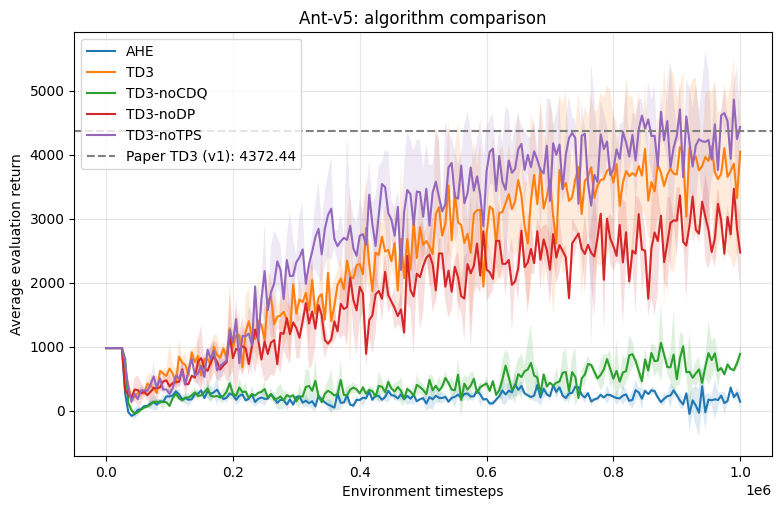

In [ ]:
plotting.plot_compare(df_ablation, base_cfg.env_id)

## Table 2-style summary

In [ ]:
per_seed = plotting.summarize(df_ablation)
display(per_seed)

# Average over seeds -> one row per variant, ordered like the paper (full TD3 first)
order = ['TD3', 'TD3-noCDQ', 'TD3-noTPS', 'TD3-noDP', 'AHE']
table2 = (per_seed.groupby('algorithm', as_index=False)
          .agg(max_return_mean=('max_return', 'mean'),
               last10_mean=('last10_avg', 'mean')))
table2['__o'] = table2['algorithm'].apply(lambda a: order.index(a) if a in order else 99)
table2 = table2.sort_values('__o').drop(columns='__o').reset_index(drop=True)
table2